# Introduction

In this project, you will build a neural network of your own design to evaluate the MNIST dataset.

Some of the benchmark results on MNIST include can be found [on Yann LeCun's page](https://webcache.googleusercontent.com/search?q=cache:stAVPik6onEJ:yann.lecun.com/exdb/mnist) and include:

88% [Lecun et al., 1998](https://hal.science/hal-03926082/document)

95.3% [Lecun et al., 1998](https://hal.science/hal-03926082v1/document)

99.65% [Ciresan et al., 2011](http://people.idsia.ch/~juergen/ijcai2011.pdf)


MNIST is a great dataset for sanity checking your models, since the accuracy levels achieved by large convolutional neural networks and small linear models are both quite high. This makes it important to be familiar with the data.

## Installation

In [1]:
# Restart the Kernel after you execute this command.

!python -m pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]3 [ipywidgets]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


**Important: Restart the Kernel at this moment**

## Imports

In [2]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list if you intend to .
The transforms module is already loaded as `transforms`.

MNIST is fortunately included in the torchvision module.
Then, you can create your dataset using the `MNIST` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/vision/stable/datasets.html#mnist)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torch.utils.data import random_split

# Define transforms for MNIST digits dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Create training set and define training dataloader
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Split the training set into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Create test set and define test dataloader
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


## Justify your preprocessing

In your own words, why did you choose the transforms you chose? If you didn't use any preprocessing steps, why not?

The transforms above are needed because:
1. We need to convert the images to PyTorch tensors using transforms.ToTensor()
2. We normalize the images to have a mean of 0.5 and a standard deviation of 0.5 using transforms.Normalize().
   This normalization centers the pixel values around 0 and scales them to a range that is more suitable for training neural networks.

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [4]:
## This cell contains a function for showing 5 images from a dataloader – DO NOT CHANGE THE CONTENTS! ##
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(int(labels[i].detach()))
    
        image = images[i].numpy()
        plt.imshow(image.T.squeeze().T)
        plt.show()

7


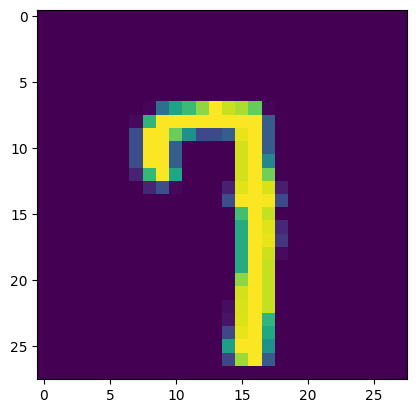

4


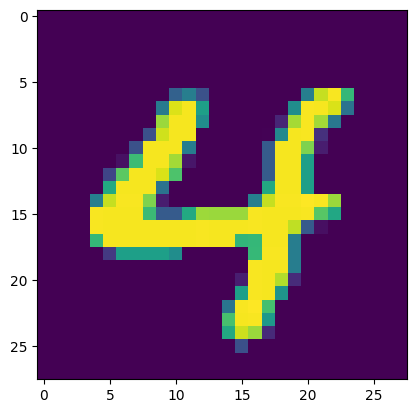

8


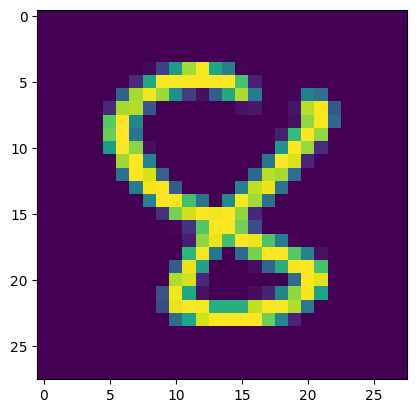

0


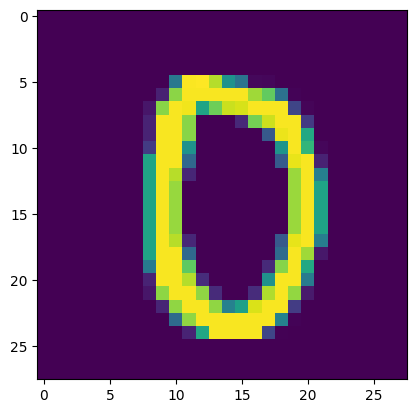

5


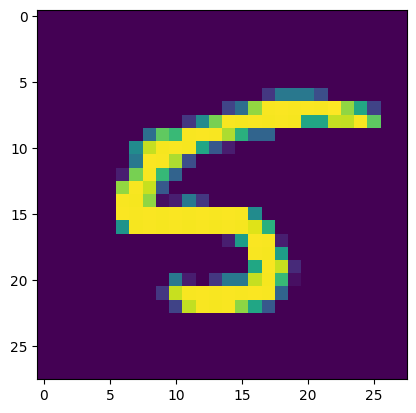

In [5]:
# Explore data

show5(train_loader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Use any architecture you like. 

*Note*: If you did not flatten your tensors in your transforms or as part of your preprocessing and you are using only `Linear` layers, make sure to use the `Flatten` layer in your network!

In [6]:
import torch.nn as nn
import torch.nn.functional as F

# Create a neural network for classifying MNIST digits
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        # First hidden layer: 784 inputs -> 128 neurons
        self.fc1 = nn.Linear(28*28, 128)
        # Second hidden layer: 128 -> 64 neurons
        self.fc2 = nn.Linear(128, 64)
        # Output layer: 64 -> 10 classes
        self.fc3 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input
        x = F.relu(self.fc1(x))  # First hidden layer with ReLU activation
        x = F.relu(self.fc2(x))  # Second hidden layer with ReLU activation
        x = self.fc3(x)  # Output layer
        x = F.log_softmax(x, dim=1)  # Apply log_softmax to get log probabilities for each class
        return x

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [7]:
# Instantiate the model, define the loss function and the optimizer
model = MNISTClassifier()
# Using NLLLoss because our model outputs log probabilities after softmax
# We need to use log_softmax in the model or apply log here
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss **during** each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [8]:
# Run the model on GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Create training and evaluation loops
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    return running_loss / len(train_loader)

def evaluate(model, validation_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
    return running_loss / len(validation_loader)

# Train and evaluate the model
# Store train and test losses for each epoch
num_epochs = 5
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    train_loss = train(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

Epoch 1/5, Train Loss: 0.4272, Validation Loss: 0.2391
Epoch 2/5, Train Loss: 0.2056, Validation Loss: 0.1735
Epoch 3/5, Train Loss: 0.1484, Validation Loss: 0.1476
Epoch 4/5, Train Loss: 0.1212, Validation Loss: 0.1301
Epoch 5/5, Train Loss: 0.1028, Validation Loss: 0.1361


Plot the training loss (and validation loss/accuracy, if recorded).

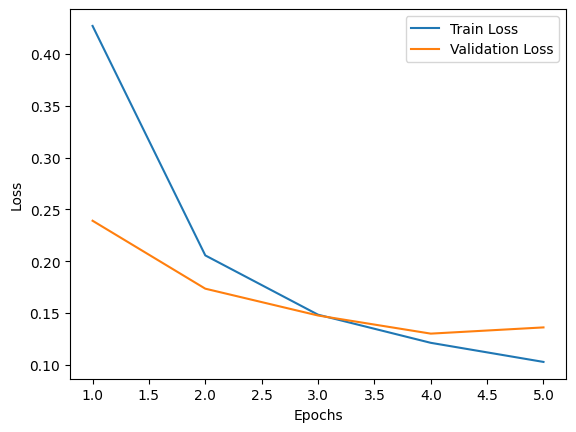

In [9]:
# Plot training and test losses
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 90%, great work, but see if you can push a bit further! 
If your accuracy is under 90%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [10]:
# Test the model on test set and calculate accuracy
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f'Accuracy of the model on the test set: {accuracy:.2f}%')

Accuracy of the model on the test set: 96.04%


## Improving your model

Once your model is done training, try tweaking your hyperparameters and training again below to improve your accuracy on the test set!

In [ ]:
# Tweak hyperparameters of the model
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        # First hidden layer: 784 inputs -> 512 neurons
        self.fc1 = nn.Linear(28*28, 512)
        # Second hidden layer: 512 -> 256 neurons
        self.fc2 = nn.Linear(512, 256)
        # Third hidden layer: 256 -> 128 classes
        self.fc3 = nn.Linear(256, 128)
        # Output layer: 128 -> 10 classes
        self.fc4 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.2)

    
    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input
        x = F.relu(self.fc1(x))  # First hidden layer with ReLU activation
        x = F.relu(self.fc2(x))  # Second hidden layer with ReLU activation
        x = F.relu(self.fc3(x))  # Third hidden layer with ReLU activation
        x = self.dropout(x)      # Apply dropout
        x = self.fc4(x)  # Output layer
        x = F.log_softmax(x, dim=1)  # Apply log_softmax to get log probabilities for each class
        return x

learning_rate = 0.01
momentum = 0.9
weight_decay = 1e-4
batch_size = 128
num_epochs = 10

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = MNISTClassifier()
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)


train_losses = []
val_losses = []
for epoch in range(num_epochs):
    train_loss = train(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

Epoch 1/10, Train Loss: 0.8031, Validation Loss: 0.3164
Epoch 2/10, Train Loss: 0.2712, Validation Loss: 0.1983
Epoch 3/10, Train Loss: 0.1926, Validation Loss: 0.1553
Epoch 4/10, Train Loss: 0.1459, Validation Loss: 0.1336
Epoch 5/10, Train Loss: 0.1223, Validation Loss: 0.1157
Epoch 6/10, Train Loss: 0.0991, Validation Loss: 0.1020
Epoch 7/10, Train Loss: 0.0866, Validation Loss: 0.0980
Epoch 8/10, Train Loss: 0.0796, Validation Loss: 0.1039
Epoch 9/10, Train Loss: 0.0638, Validation Loss: 0.0994
Epoch 10/10, Train Loss: 0.0637, Validation Loss: 0.0836


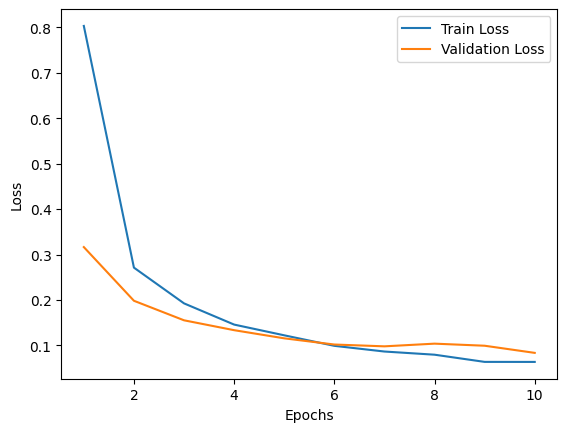

In [22]:
# Plot training and test losses
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
# Test the model on test set and calculate accuracy
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f'Accuracy of the model on the test set: {accuracy:.2f}%')

Accuracy of the model on the test set: 97.40%


## Saving your model
Using `torch.save`, save your model for future loading.

In [24]:
# Save the trained model
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved successfully!")

# Load the model
loaded_model = MNISTClassifier()
loaded_model.load_state_dict(torch.load('mnist_model.pth'))
loaded_model.to(device)
loaded_model.eval()
print("Model loaded successfully!")

# Verify the loaded model works by testing on a batch
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = loaded_model(images)
_, predicted = torch.max(outputs, 1)
print(f"Sample predictions: {predicted[:10].cpu().numpy()}")
print(f"Actual labels: {labels[:10].cpu().numpy()}")

Model saved successfully!
Model loaded successfully!
Sample predictions: [7 2 1 0 4 1 4 9 5 9]
Actual labels: [7 2 1 0 4 1 4 9 5 9]
